<a href="https://colab.research.google.com/github/JohnUfo/python-and-scikit-tutorial/blob/main/Logistic_Regression_with_Scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
import os

In [78]:
data_dir = 'drive/MyDrive/weather-dataset-rattle-package'

In [79]:
os.listdir(data_dir)

['weatherAUS.csv', '.ipynb_checkpoints']

In [80]:
train_csv = data_dir + '/weatherAUS.csv'

In [81]:
import pandas as pd

In [82]:
raw_df = pd.read_csv(train_csv)

In [83]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

Clearing rows which do not have values

In [84]:
raw_df.dropna(subset=['RainToday','RainTomorrow'], inplace=True)

In [85]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           140787 non-null  object 
 1   Location       140787 non-null  object 
 2   MinTemp        140319 non-null  float64
 3   MaxTemp        140480 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81093 non-null   float64
 6   Sunshine       73982 non-null   float64
 7   WindGustDir    131624 non-null  object 
 8   WindGustSpeed  131682 non-null  float64
 9   WindDir9am     131127 non-null  object 
 10  WindDir3pm     137117 non-null  object 
 11  WindSpeed9am   139732 non-null  float64
 12  WindSpeed3pm   138256 non-null  float64
 13  Humidity9am    139270 non-null  float64
 14  Humidity3pm    137286 non-null  float64
 15  Pressure9am    127044 non-null  float64
 16  Pressure3pm    127018 non-null  float64
 17  Cloud9am       88162 non-null   fl

In [86]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [87]:
px.histogram(raw_df, x='Location', title='Location vs Rainy Days', color='RainToday')

In [88]:
px.histogram(raw_df, x='Temp3pm',title='Temperature at 3pm vs Rain Tomorrow', color='RainTomorrow')

In [89]:
px.histogram(raw_df, x='RainTomorrow',title='Rain Today vs Rain Tomorrow', color='RainToday')

In [90]:
px.scatter(raw_df.sample(10000), title='Min Temp vs Max Temp', x='MinTemp', y='MaxTemp', color='RainToday')

In [91]:
from sklearn.model_selection import train_test_split
train_val_df, test_df = train_test_split(raw_df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42)

<Axes: title={'center': 'No of Rows per Year'}, xlabel='Date', ylabel='count'>

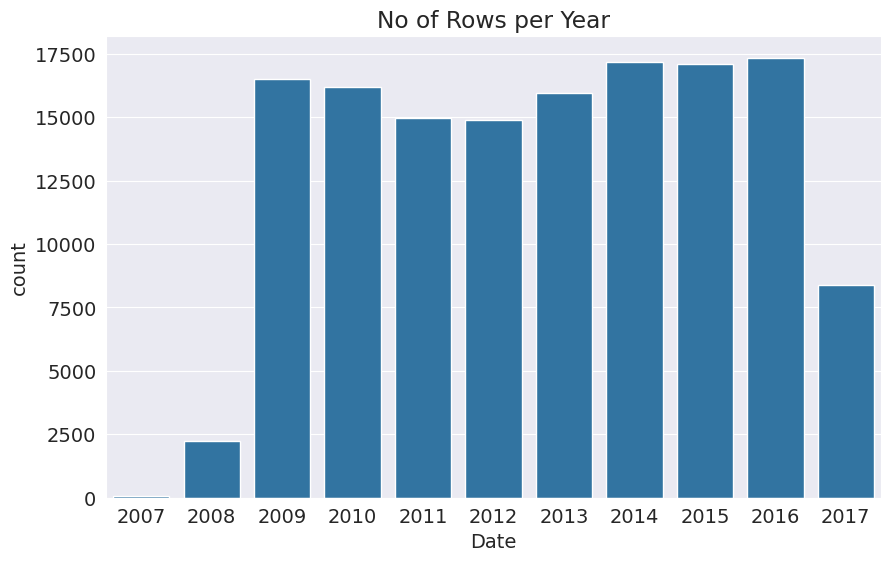

In [92]:
plt.title('No of Rows per Year')
sns.countplot(x=pd.to_datetime(raw_df.Date).dt.year)

# Chronological Split

In [93]:
year = pd.to_datetime(raw_df.Date).dt.year

train_df = raw_df[year < 2015]
val_df = raw_df[year == 2015]
test_df = raw_df[year > 2015]

print('train_df.shape: ', train_df.shape)
print('val_df.shape: ', val_df.shape)
print('test_df.shape: ', test_df.shape)

train_df.shape:  (97988, 23)
val_df.shape:  (17089, 23)
test_df.shape:  (25710, 23)


In [94]:
input_cols = list(train_df.columns)[1:-1]
target_col = 'RainTomorrow'

In [95]:
print(input_cols)

['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']


In [96]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()
test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

# Selecting Numeric and Categorical data

In [97]:
import numpy as np

In [98]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [99]:
numeric_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm']

In [100]:
categorical_cols

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [101]:
train_inputs[categorical_cols].nunique()

,0
Location,49
WindGustDir,16
WindDir9am,16
WindDir3pm,16
RainToday,2


# MISSING VALUES

In [102]:
raw_df[numeric_cols].isna().sum()

,0
MinTemp,468
MaxTemp,307
Rainfall,0
Evaporation,59694
Sunshine,66805
WindGustSpeed,9105
WindSpeed9am,1055
WindSpeed3pm,2531
Humidity9am,1517
Humidity3pm,3501


In [103]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')


In [104]:
imputer.fit(raw_df[numeric_cols])

SimpleImputer()

In [105]:
print(numeric_cols)

['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [106]:
list(imputer.statistics_)

[np.float64(12.18482386562048),
 np.float64(23.235120301822324),
 np.float64(2.349974074310839),
 np.float64(5.472515506887154),
 np.float64(7.630539861047281),
 np.float64(39.97051988882308),
 np.float64(13.990496092519967),
 np.float64(18.631140782316862),
 np.float64(68.82683277087672),
 np.float64(51.44928834695453),
 np.float64(1017.6545771543717),
 np.float64(1015.2579625879797),
 np.float64(4.431160817585808),
 np.float64(4.499250233195188),
 np.float64(16.98706638787991),
 np.float64(21.69318269001107)]

In [107]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [108]:
train_inputs[numeric_cols].isna().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0


In [109]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [110]:
scaler.fit(raw_df[numeric_cols])

MinMaxScaler()

In [111]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [112]:
train_inputs

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,Albury,0.516509,0.523629,0.001617,0.037741,0.526244,W,0.294574,W,WNW,...,0.275862,0.71,0.22,0.449587,0.4800,0.888889,0.499917,0.508439,0.522073,No
1,Albury,0.375000,0.565217,0.000000,0.037741,0.526244,WNW,0.294574,NNW,WSW,...,0.252874,0.44,0.25,0.497521,0.4912,0.492351,0.499917,0.514768,0.570058,No
2,Albury,0.504717,0.576560,0.000000,0.037741,0.526244,WSW,0.310078,W,WSW,...,0.298851,0.38,0.30,0.447934,0.5056,0.492351,0.222222,0.594937,0.548944,No
3,Albury,0.417453,0.620038,0.000000,0.037741,0.526244,NE,0.139535,SE,E,...,0.103448,0.45,0.16,0.613223,0.5712,0.492351,0.499917,0.533755,0.612284,No
4,Albury,0.613208,0.701323,0.002695,0.037741,0.526244,W,0.271318,ENE,NW,...,0.229885,0.82,0.33,0.500826,0.4624,0.777778,0.888889,0.527426,0.673704,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144548,Uluru,0.599057,0.718336,0.000000,0.037741,0.526244,SSE,0.286822,ESE,SSE,...,0.298851,0.22,0.13,0.555372,0.5232,0.492351,0.499917,0.651899,0.714012,No
144549,Uluru,0.556604,0.786389,0.000000,0.037741,0.526244,NE,0.193798,ENE,SW,...,0.229885,0.16,0.08,0.530579,0.4880,0.492351,0.499917,0.761603,0.771593,No
144550,Uluru,0.608491,0.805293,0.000000,0.037741,0.526244,ESE,0.255814,ESE,SSE,...,0.103448,0.15,0.08,0.519008,0.4944,0.492351,0.499917,0.778481,0.788868,No
144551,Uluru,0.674528,0.818526,0.000000,0.037741,0.526244,ESE,0.286822,ESE,SSW,...,0.195402,0.22,0.09,0.553719,0.5136,0.492351,0.499917,0.780591,0.817658,No


In [113]:
from sklearn.preprocessing import OneHotEncoder

In [114]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(raw_df[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [115]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols].fillna('Unknown'))
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols].fillna('Unknown'))
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols].fillna('Unknown'))

print("Shape of train_inputs after one-hot encoding:", train_inputs.shape)
print("Shape of val_inputs after one-hot encoding:", val_inputs.shape)
print("Shape of test_inputs after one-hot encoding:", test_inputs.shape)

/tmp/ipython-input-3427921065.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-3427921065.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-3427921065.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-3427921065.py:1: PerformanceWarning:

Shape of train_inputs after one-hot encoding: (97988, 123)
Shape of val_inputs after one-hot encoding: (17089, 123)
Shape of test_inputs after one-hot encoding: (25710, 123)


/tmp/ipython-input-3427921065.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-3427921065.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-3427921065.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-3427921065.py:3: PerformanceWarning:

In [116]:
test_inputs

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes
2498,Albury,0.681604,0.801512,0.000000,0.037741,0.526244,ENE,0.372093,NaN,ESE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2499,Albury,0.693396,0.725898,0.001078,0.037741,0.526244,SSE,0.341085,SSE,SE,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2500,Albury,0.634434,0.527410,0.005930,0.037741,0.526244,ENE,0.325581,ESE,ENE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2501,Albury,0.608491,0.538752,0.042049,0.037741,0.526244,SSE,0.255814,SE,SSE,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2502,Albury,0.566038,0.523629,0.018329,0.037741,0.526244,ENE,0.193798,SE,SSE,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,Uluru,0.283019,0.502836,0.000000,0.037741,0.526244,E,0.193798,ESE,E,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
145455,Uluru,0.266509,0.533081,0.000000,0.037741,0.526244,E,0.193798,SE,ENE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
145456,Uluru,0.285377,0.568998,0.000000,0.037741,0.526244,NNW,0.124031,SE,N,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
145457,Uluru,0.327830,0.599244,0.000000,0.037741,0.526244,N,0.240310,SE,WNW,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [117]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
test_inputs.to_parquet('test_inputs.parquet')

In [118]:
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')
pd.DataFrame(test_targets).to_parquet('test_targets.parquet')

In [119]:
train_inputs = pd.read_parquet('train_inputs.parquet')
val_inputs = pd.read_parquet('val_inputs.parquet')
test_inputs = pd.read_parquet('test_inputs.parquet')

train_targets = pd.read_parquet('train_targets.parquet')[target_col]
val_targets = pd.read_parquet('val_targets.parquet')[target_col]
test_targets = pd.read_parquet('test_targets.parquet')[target_col]

In [120]:
from sklearn.linear_model import LogisticRegression

In [121]:
model = LogisticRegression(solver='liblinear')

In [122]:
model.fit(train_inputs[numeric_cols + encoded_cols], train_targets)

LogisticRegression(solver='liblinear')

In [123]:
weight_df = pd.DataFrame({
    'features': numeric_cols + encoded_cols,
    'weight': model.coef_[0]
})

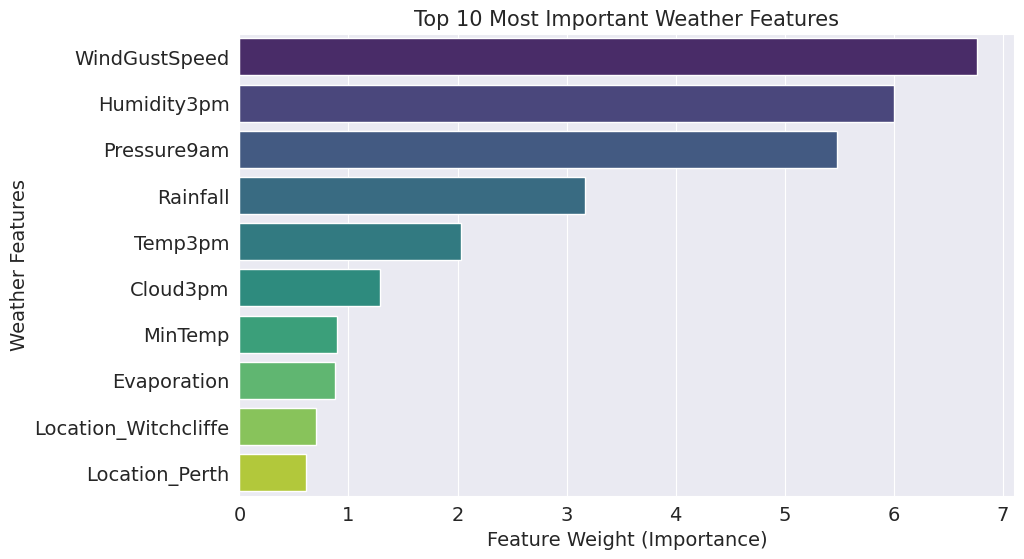

In [124]:
# 1. Grafik o'lchamini to'g'irlaymiz (figsize)
# (10, 6) o'lchami 10 ta feature uchun juda mos keladi.
plt.figure(figsize=(10, 6))

# 2. Eng muhim 10 ta featureni ajratib olamiz
top_10_weights = weight_df.sort_values('weight', ascending=False).head(10)

# 3. Rang-barang grafik chizamiz
sns.barplot(
    data=top_10_weights,
    x='weight',
    y='features',
    hue='features',      # Har bir bar uchun alohida rang beradi
    palette='viridis',   # Chiroyli ranglar to'plami
    legend=False         # Ortqicha legendni o'chirib qo'yamiz
)

# 4. Sarlavha va nomlar qo'shamiz
plt.title('Top 10 Most Important Weather Features', fontsize=15)
plt.xlabel('Feature Weight (Importance)')
plt.ylabel('Weather Features')

plt.show()

In [125]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

# Data Preparation & Internal Check
**Filtering**: X_train, X_val, and X_test are created to filter out
original text columns. We only keep the "clean" columns (numeric + encoded) that the model understands.

**Internal Performance Check**: model.predict(X_train) is not training. It is an internal check to see how well the model predicts the data it has already seen.

**Real Validation**: The true test of the model happens only when we use X_val (data the model has never seen before).

In [126]:
train_preds = model.predict(X_train)

In [127]:
from sklearn.metrics import accuracy_score

In [128]:
accuracy_score(train_targets, train_preds)

0.8519716700004082

Probability of how confident about the prediction
* predict(): Shunchaki yakuniy javobni beradi ("No" yoki "Yes").
* predict_proba(): Modelning har bir javob uchun necha foiz "ishonchi" borligini ko'rsatadi.

In [129]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.94410402, 0.05589598],
       [0.94077867, 0.05922133],
       [0.96099488, 0.03900512],
       ...,
       [0.98747367, 0.01252633],
       [0.98331684, 0.01668316],
       [0.87429661, 0.12570339]])

In [130]:
model.classes_

array(['No', 'Yes'], dtype=object)

In [131]:
from sklearn.metrics import confusion_matrix

In [132]:
confusion_matrix(train_targets,train_preds, normalize='true')

array([[0.94622654, 0.05377346],
       [0.477475  , 0.522525  ]])

In [133]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)
    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets,preds,normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title("Confusion Matrix for " + name)

Accuracy: 85.41%


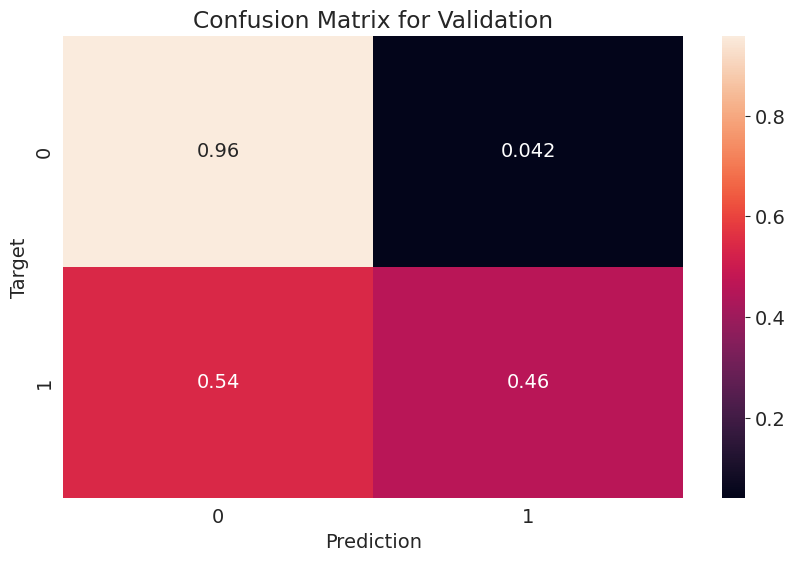

In [134]:
val_preds = predict_and_plot(X_val,val_targets,'Validation')

Accuracy: 84.20%


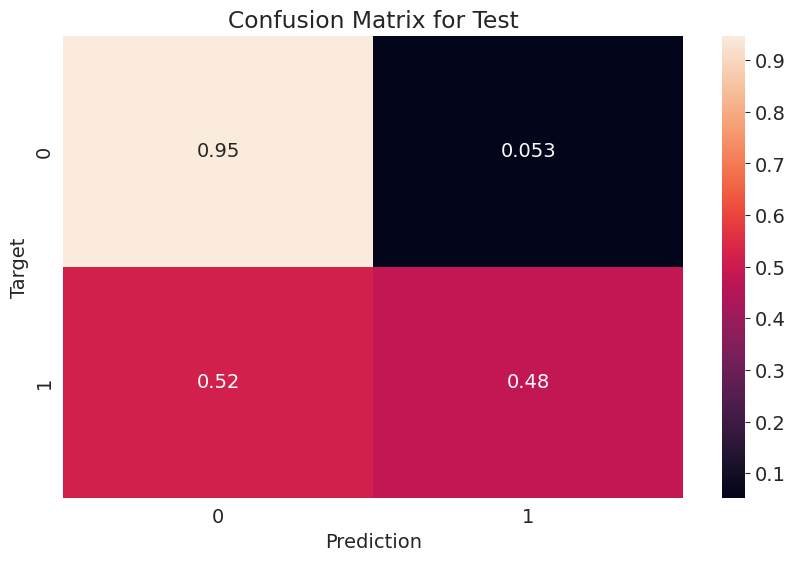

In [135]:
test_preds = predict_and_plot(X_test,test_targets,'Test')

# NEW INPUT DATA

In [136]:
new_input = {'Date': '2021-06-19',
'Location': 'Katherine',
'MinTemp': 23.4,
'MaxTemp': 33.2,
'Rainfall': 10.2,
'Evaporation': 4.2,
'Sunshine': np.nan,
'WindGustDir': 'NNW',
'WindGustSpeed': 52.0,
'WindDir9am': 'NW',
'WindDir3pm': 'NNE',
'WindSpeed9am': 13.0,
'WindSpeed3pm': 20.0,
'Humidity9am': 89.0,
'Humidity3pm': 58.0,
'Pressure9am': 1004.8,
'Pressure3pm': 1001.5,
'Cloud9am': 8.0,
'Cloud3pm': 5.0,
'Temp9am': 25.7,
'Temp3pm': 33.0,
'RainToday': 'Yes'}

In [137]:
new_input_df = pd.DataFrame([new_input])
new_input_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,2021-06-19,Katherine,23.4,33.2,10.2,4.2,NaN,NNW,52.0,NW,...,20.0,89.0,58.0,1004.8,1001.5,8.0,5.0,25.7,33.0,Yes


In [138]:
new_input_df[numeric_cols] = imputer.transform(new_input_df[numeric_cols])
new_input_df[numeric_cols] = scaler.transform(new_input_df[numeric_cols])
new_input_df[encoded_cols] = encoder.transform(new_input_df[categorical_cols])
new_input_df

/tmp/ipython-input-4100014410.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-4100014410.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-4100014410.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-4100014410.py:3: PerformanceWarning:

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes
0,2021-06-19,Katherine,0.752358,0.718336,0.027493,0.028966,0.526244,NNW,0.356589,NW,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [139]:
X_new_input = new_input_df[numeric_cols + encoded_cols]
X_new_input

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes
0,0.752358,0.718336,0.027493,0.028966,0.526244,0.356589,0.1,0.229885,0.89,0.58,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [140]:
prediction = model.predict(X_new_input)[0]
prediction

'Yes'

In [141]:
prob = model.predict_proba(X_new_input)[0]
prob

array([0.47991272, 0.52008728])

In [142]:
def predict_input(single_input):
    input_df = pd.DataFrame([single_input])
    input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    encoded_data = encoder.transform(input_df[categorical_cols])
    encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols, index=input_df.index)
    input_df = pd.concat([input_df, encoded_df], axis=1)
    x_input = input_df[numeric_cols + encoded_cols]
    pred = model.predict(x_input)[0]
    prob = model.predict_proba(x_input)[0][list(model.classes_).index(pred)]

    return pred, prob

In [143]:
new_input = {'Date': '2021-06-19',
'Location': 'Albury',
'MinTemp': 23.2,
'MaxTemp': 33.2,
'Rainfall': 10.2,
'Evaporation': 4.2,
'Sunshine': np.nan,
'WindGustDir': 'NNW',
'WindGustSpeed': 52.0,
'WindDir9am': 'NW',
'WindDir3pm': 'NNE',
'WindSpeed9am': 13.0,
'WindSpeed3pm': 20.0,
'Humidity9am': 89.0,
'Humidity3pm': 58.0,
'Pressure9am': 1004.8,
'Pressure3pm': 1001.5,
'Cloud9am': 8.0,
'Cloud3pm': 5.0,
'Temp9am': 25.7,
'Temp3pm': 33.0,
'RainToday': 'Yes'}

In [144]:
result = predict_input(new_input)
result

('Yes', np.float64(0.792650655109054))

#  Modelni saqlash: joblib (Saving the Brain)

In [145]:
import joblib

In [146]:
aussie_rain = {
'model': model,
'imputer': imputer,
'scaler': scaler,
'encoder': encoder,
'input_cols': input_cols,
'target_col': target_col,
'numeric_cols': numeric_cols,
'categorical_cols': categorical_cols,
'encoded_cols': encoded_cols
}

In [147]:
joblib.dump(aussie_rain, 'aussie_rain.joblib')

['aussie_rain.joblib']

In [148]:
aussie_rain2 = joblib.load('aussie_rain.joblib')

In [150]:
aussie_rain2

{'model': LogisticRegression(solver='liblinear'),
 'imputer': SimpleImputer(),
 'scaler': MinMaxScaler(),
 'encoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 'input_cols': ['Location',
  'MinTemp',
  'MaxTemp',
  'Rainfall',
  'Evaporation',
  'Sunshine',
  'WindGustDir',
  'WindGustSpeed',
  'WindDir9am',
  'WindDir3pm',
  'WindSpeed9am',
  'WindSpeed3pm',
  'Humidity9am',
  'Humidity3pm',
  'Pressure9am',
  'Pressure3pm',
  'Cloud9am',
  'Cloud3pm',
  'Temp9am',
  'Temp3pm',
  'RainToday'],
 'target_col': 'RainTomorrow',
 'numeric_cols': ['MinTemp',
  'MaxTemp',
  'Rainfall',
  'Evaporation',
  'Sunshine',
  'WindGustSpeed',
  'WindSpeed9am',
  'WindSpeed3pm',
  'Humidity9am',
  'Humidity3pm',
  'Pressure9am',
  'Pressure3pm',
  'Cloud9am',
  'Cloud3pm',
  'Temp9am',
  'Temp3pm'],
 'categorical_cols': ['Location',
  'WindGustDir',
  'WindDir9am',
  'WindDir3pm',
  'RainToday'],
 'encoded_cols': ['Location_Adelaide',
  'Location_Albany',
  'Location_Albury',
  'L